<a href="https://colab.research.google.com/github/deborahpongeluppe/Deborahpongeluppe/blob/main/PROJETOFINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de operadores - CallMeMaybe

O objetivo dessa análise será identificar os operadores ineficientes do serviço de telefonia virtual CallMeMaybe, nessa análise vamos verificar chamadas recebidas perdidas tanto internas quanto externas, também será verificado o tempo de espera e o baixo volume de chamadas ativas, essa análise será composta por uma análise exploratória de dados, a identificação de operadores ineficientes, será composta também por testes de hipóteses estatísticas.

In [ ]:
import pandas as pd

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving telecom_clients.csv to telecom_clients (1).csv


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving telecom_dataset_new.csv to telecom_dataset_new (1).csv


In [ ]:
telecom = pd.read_csv('telecom_clients.csv')
telecom.head()

,user_id,tariff_plan,date_start
0,166713,A,2019-08-15
1,166901,A,2019-08-23
2,168527,A,2019-10-29
3,167097,A,2019-09-01
4,168193,A,2019-10-16


In [ ]:
telecom_new = pd.read_csv('telecom_dataset_new.csv')
telecom_new.head()

,user_id,date,direction,internal,operator_id,is_missed_call,calls_count,call_duration,total_call_duration
0,166377,2019-08-04 00:00:00+03:00,in,False,NaN,True,2,0,4
1,166377,2019-08-05 00:00:00+03:00,out,True,880022.0,True,3,0,5
2,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,True,1,0,1
3,166377,2019-08-05 00:00:00+03:00,out,True,880020.0,False,1,10,18
4,166377,2019-08-05 00:00:00+03:00,out,False,880022.0,True,3,0,25


In [ ]:
telecom.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 732 entries, 0 to 731
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      732 non-null    int64 
 1   tariff_plan  732 non-null    object
 2   date_start   732 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.3+ KB


In [ ]:
telecom_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53902 entries, 0 to 53901
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              53902 non-null  int64  
 1   date                 53902 non-null  object 
 2   direction            53902 non-null  object 
 3   internal             53785 non-null  object 
 4   operator_id          45730 non-null  float64
 5   is_missed_call       53902 non-null  bool   
 6   calls_count          53902 non-null  int64  
 7   call_duration        53902 non-null  int64  
 8   total_call_duration  53902 non-null  int64  
dtypes: bool(1), float64(1), int64(4), object(3)
memory usage: 3.3+ MB


In [ ]:
print(telecom.isnull().sum())

user_id        0
tariff_plan    0
date_start     0
dtype: int64


In [ ]:
print(telecom_new.isnull().sum())

user_id                   0
date                      0
direction                 0
internal                117
operator_id            8172
is_missed_call            0
calls_count               0
call_duration             0
total_call_duration       0
dtype: int64


In [ ]:
print(f"Total de registros: {telecom_new.shape[0]}")
print(f"Porcentagem de operator_id ausentes: {(8172/telecom_new.shape[0])*100:.2f}%")

Total de registros: 53902
Porcentagem de operator_id ausentes: 15.16%


In [ ]:
print(telecom_new[telecom_new['operator_id'].isnull()]['is_missed_call'].value_counts())

is_missed_call
True     8050
False     122
Name: count, dtype: int64


In [ ]:
print("Chamadas com operator_id ausente:")
print(telecom_new[telecom_new['operator_id'].isnull()]['is_missed_call'].value_counts())
print("\nPorcentagens:")
print(telecom_new[telecom_new['operator_id'].isnull()]['is_missed_call'].value_counts(normalize=True) * 100)

Chamadas com operator_id ausente:
is_missed_call
True     8050
False     122
Name: count, dtype: int64

Porcentagens:
is_missed_call
True     98.507097
False     1.492903
Name: proportion, dtype: float64


É possível notar que cerca de 8050 dos valores ausentes em id_operator é chamadas perdidas, o que faz sentido pois se elas não foram atendidas elas não chegaram a um operador especifico.

In [ ]:
chamadas_atendidas = telecom_new[(telecom_new['operator_id'].notna()) &
                                 (telecom_new['is_missed_call'] == False)]
print(f"Chamadas atendidas por operadores: {len(chamadas_atendidas)}")
print(f"Porcentagem do total: {(len(chamadas_atendidas)/len(telecom_new))*100:.2f}%")

Chamadas atendidas por operadores: 30212
Porcentagem do total: 56.05%


In [ ]:
print("=== ANÁLISE DE VALORES AUSENTES ===")
print(f"Total de registros: {telecom_new.shape[0]}")
print(f"Total de colunas: {telecom_new.shape[1]}")
print("\nValores ausentes por coluna:")
missing_data = telecom_new.isnull().sum()
missing_percent = (missing_data / len(telecom_new)) * 100

for col in telecom_new.columns:
    if missing_data[col] > 0:
        print(f"{col}: {missing_data[col]} ({missing_percent[col]:.2f}%)")
    else:
        print(f"{col}: 0 (0.00%)")

=== ANÁLISE DE VALORES AUSENTES ===
Total de registros: 53902
Total de colunas: 9

Valores ausentes por coluna:
user_id: 0 (0.00%)
date: 0 (0.00%)
direction: 0 (0.00%)
internal: 117 (0.22%)
operator_id: 8172 (15.16%)
is_missed_call: 0 (0.00%)
calls_count: 0 (0.00%)
call_duration: 0 (0.00%)
total_call_duration: 0 (0.00%)


In [ ]:
print("=== ANÁLISE DOS VALORES AUSENTES EM 'internal' ===")
internal_missing = telecom_new[telecom_new['internal'].isnull()]

print(f"Registros com 'internal' ausente: {len(internal_missing)}")
print("\nDistribuição por 'direction':")
print(internal_missing['direction'].value_counts())
print("\nSão chamadas perdidas?")
print(internal_missing['is_missed_call'].value_counts())

=== ANÁLISE DOS VALORES AUSENTES EM 'internal' ===
Registros com 'internal' ausente: 117

Distribuição por 'direction':
direction
in     115
out      2
Name: count, dtype: int64

São chamadas perdidas?
is_missed_call
False    59
True     58
Name: count, dtype: int64


Aqui podemos ver que os valores ausentes em internal significa que 115 são chamadas de entrada e 2 são chamadas de saída e em relação as chamadas 59 não são chamadas perdidas e 58 são chamadas perdidas. Apesar desse resultado prefiro manter os valores ausentes pois são valores que não são capazes de alterar o objetivo principal da análise.

In [ ]:
print("\n=== ANÁLISE DE DUPLICADOS ===")
print(f"Registros duplicados: {telecom_new.duplicated().sum()}")
print(f"Porcentagem de duplicados: {(telecom_new.duplicated().sum()/len(telecom_new))*100:.2f}%")


=== ANÁLISE DE DUPLICADOS ===
Registros duplicados: 4900
Porcentagem de duplicados: 9.09%


In [ ]:
duplicados = telecom_new[telecom_new.duplicated(keep=False)]
print(duplicados.head())

    user_id                       date direction internal  operator_id  \
6    166377  2019-08-05 00:00:00+03:00       out    False     880020.0   
8    166377  2019-08-05 00:00:00+03:00       out    False     880020.0   
27   166377  2019-08-12 00:00:00+03:00        in    False          NaN   
28   166377  2019-08-12 00:00:00+03:00        in    False          NaN   
38   166377  2019-08-14 00:00:00+03:00        in    False          NaN   

    is_missed_call  calls_count  call_duration  total_call_duration  
6             True            8              0                   50  
8             True            8              0                   50  
27            True            2              0                   34  
28            True            2              0                   34  
38            True            1              0                    3  


In [ ]:
print("\n=== REMOÇÃO DE DUPLICADOS ===")
print(f"Registros antes da remoção: {len(telecom_new)}")
telecom_clean = telecom_new.drop_duplicates(keep='first')
print(f"Registros após remoção: {len(telecom_clean)}")
print(f"Duplicados removidos: {len(telecom_new) - len(telecom_clean)}")
print(f"Porcentagem removida: {((len(telecom_new) - len(telecom_clean))/len(telecom_new))*100:.2f}%")


=== REMOÇÃO DE DUPLICADOS ===
Registros antes da remoção: 53902
Registros após remoção: 49002
Duplicados removidos: 4900
Porcentagem removida: 9.09%


Como tratamento para os duplicados, foram encontrados alguns duplicados nos dados e após inverstigar os padrões, foi descoberto que os duplicados eram em todos os aspectos, ou seja, eram duplicados completos, com base nessa informação foi feita a remoção dos duplicados mantendo o primeiro registro, sendo assim feita a limpeza dos dados.

In [ ]:
print(telecom_new['is_missed_call'].value_counts())

is_missed_call
False    30334
True     23568
Name: count, dtype: int64


In [ ]:
taxa_perdidas = (telecom_new['is_missed_call'].sum() / len(telecom_new)) * 100
print(f"Taxa de chamadas perdidas: {taxa_perdidas:.2f}%")

Taxa de chamadas perdidas: 43.72%


Aqui foi calculado a taxa de chamadas perdidas e podemos ver que 43% das chamadas foram perdidas, isso nos mostra um valor alto de chamadas perdidas nos dados.

In [ ]:
print("Número de operadores:", telecom_new['operator_id'].nunique())
print("\nDistribuição de chamadas por operador:")
print(telecom_new['operator_id'].value_counts().head(10))

Número de operadores: 1092

Distribuição de chamadas por operador:
operator_id
901884.0    348
901880.0    337
893804.0    325
885876.0    319
891410.0    290
887276.0    289
891414.0    277
885890.0    277
905538.0    269
889410.0    262
Name: count, dtype: int64


In [ ]:
operator_metrics = telecom_new.groupby('operator_id').agg({
    'is_missed_call': ['count', 'sum']}).round(2)
operator_metrics.columns = ['total_calls', 'missed_calls']
operator_metrics['missed_call_rate'] = (
    operator_metrics['missed_calls'] / operator_metrics['total_calls'] * 100
).round(2)
print("Métricas por operador (primeiros 10):")
print(operator_metrics.head(10))
print("\nEstatísticas das taxas de chamadas perdidas:")
print(operator_metrics['missed_call_rate'].describe())
print("\nTop 10 operadores com MAIORES taxas de perda:")
worst_operators = operator_metrics.sort_values('missed_call_rate', ascending=False).head(10)
print(worst_operators)

Métricas por operador (primeiros 10):
             total_calls  missed_calls  missed_call_rate
operator_id                                             
879896.0             128            50             39.06
879898.0             251           100             39.84
880020.0              22             7             31.82
880022.0              76            33             43.42
880026.0             198            94             47.47
880028.0             226            91             40.27
880240.0              14             8             57.14
881278.0               8             7             87.50
882476.0               3             0              0.00
882478.0               3             1             33.33

Estatísticas das taxas de chamadas perdidas:
count    1092.000000
mean       31.430293
std        23.136340
min         0.000000
25%        12.500000
50%        33.330000
75%        46.150000
max       100.000000
Name: missed_call_rate, dtype: float64

Top 10 operadores com MA

In [ ]:
min_calls = 30
filtered_operators = operator_metrics[operator_metrics['total_calls'] >= min_calls].copy()
print(f"Operadores com pelo menos {min_calls} chamadas: {len(filtered_operators)}")
print(f"Operadores filtrados: {len(operator_metrics) - len(filtered_operators)}")
print("\nEstatísticas após filtro:")
print(filtered_operators['missed_call_rate'].describe())

Operadores com pelo menos 30 chamadas: 462
Operadores filtrados: 630

Estatísticas após filtro:
count    462.000000
mean      34.348831
std       14.064873
min        0.000000
25%       27.450000
50%       34.940000
75%       44.865000
max       67.650000
Name: missed_call_rate, dtype: float64


In [ ]:
q75 = filtered_operators['missed_call_rate'].quantile(0.75)
q90 = filtered_operators['missed_call_rate'].quantile(0.90)
print(f"75º percentil: {q75:.2f}%")
print(f"90º percentil: {q90:.2f}%")
filtered_operators['efficiency_category'] = 'Eficiente'
filtered_operators.loc[filtered_operators['missed_call_rate'] > q75, 'efficiency_category'] = 'Ineficiente'
filtered_operators.loc[filtered_operators['missed_call_rate'] > q90, 'efficiency_category'] = 'Muito Ineficiente'
print("\nClassificação de eficiência:")
print(filtered_operators['efficiency_category'].value_counts())

75º percentil: 44.86%
90º percentil: 51.22%

Classificação de eficiência:
efficiency_category
Eficiente            346
Ineficiente           70
Muito Ineficiente     46
Name: count, dtype: int64


Com esse percentis calculados podemos ver que cerca de 75% dos operadores tem taxa de chamadas perdidas abaixo desse valor 44%, e apenas 10% desses operadores tem taxa acima de 51% para a distribuição da classificação podemos considerar eficiente 346 operadores (74.9%), Ineficiente 70 operadores (15.2%) e muito Ineficiente 46 operadores (9.9%)

In [ ]:
print("Colunas disponíveis no dataset:")
print(telecom_new.columns.tolist())
print("\nTipos de dados:")
print(telecom_new.dtypes)

Colunas disponíveis no dataset:
['user_id', 'date', 'direction', 'internal', 'operator_id', 'is_missed_call', 'calls_count', 'call_duration', 'total_call_duration']

Tipos de dados:
user_id                  int64
date                    object
direction               object
internal                object
operator_id            float64
is_missed_call            bool
calls_count              int64
call_duration            int64
total_call_duration      int64
dtype: object


In [ ]:
Q1 = filtered_operators['missed_call_rate'].quantile(0.25)  # 27.45%
Q3 = filtered_operators['missed_call_rate'].quantile(0.75)  # 44.86%
IQR = Q3 - Q1
print(f"Q1 (25º percentil): {Q1:.2f}%")
print(f"Q3 (75º percentil): {Q3:.2f}%")
print(f"IQR: {IQR:.2f}%")
upper_fence = Q3 + 1.5 * IQR
print(f"Limite superior (Q3 + 1.5*IQR): {upper_fence:.2f}%")
mean_rate = filtered_operators['missed_call_rate'].mean()
std_rate = filtered_operators['missed_call_rate'].std()
z_threshold = 1.5
print(f"\nMédia: {mean_rate:.2f}%")
print(f"Desvio padrão: {std_rate:.2f}%")
print(f"Limite Z-score (média + 1.5*std): {mean_rate + z_threshold * std_rate:.2f}%")

Q1 (25º percentil): 27.45%
Q3 (75º percentil): 44.86%
IQR: 17.41%
Limite superior (Q3 + 1.5*IQR): 70.99%

Média: 34.35%
Desvio padrão: 14.06%
Limite Z-score (média + 1.5*std): 55.45%


In [ ]:
operator_volume = telecom_new.groupby('operator_id').agg({
    'calls_count': 'sum',
    'call_duration': ['mean', 'median', 'std'],
    'total_call_duration': 'sum',
    'is_missed_call': ['count', 'sum']
}).round(2)
operator_volume.columns = ['_'.join(col).strip() for col in operator_volume.columns]
print("Métricas de volume por operador:")
print(operator_volume.head())

Métricas de volume por operador:
             calls_count_sum  call_duration_mean  call_duration_median  \
operator_id                                                              
879896.0                1131              650.48                  27.0   
879898.0                7974             1111.07                  63.0   
880020.0                  54              104.09                  36.0   
880022.0                 219              240.84                  41.0   
880026.0                2439              856.94                  29.5   

             call_duration_std  total_call_duration_sum  is_missed_call_count  \
operator_id                                                                     
879896.0               1668.07                    97427                   128   
879898.0               1873.05                   391850                   251   
880020.0                219.54                     2624                    22   
880022.0                465.81             

In [ ]:
operator_volume['avg_call_duration'] = operator_volume['call_duration_mean']
operator_volume['total_calls'] = operator_volume['is_missed_call_count']
operator_volume['missed_calls'] = operator_volume['is_missed_call_sum']
operator_volume['missed_call_rate'] = (operator_volume['missed_calls'] / operator_volume['total_calls'] * 100).round(2)
days_in_period = telecom_new['date'].nunique()
operator_volume['calls_per_day'] = (operator_volume['total_calls'] / days_in_period).round(2)
print(f"Período de análise: {days_in_period} dias")
print("\nMétricas expandidas:")
print(operator_volume[['total_calls', 'missed_call_rate', 'avg_call_duration', 'calls_per_day']].head())

Período de análise: 119 dias

Métricas expandidas:
             total_calls  missed_call_rate  avg_call_duration  calls_per_day
operator_id                                                                 
879896.0             128             39.06             650.48           1.08
879898.0             251             39.84            1111.07           2.11
880020.0              22             31.82             104.09           0.18
880022.0              76             43.42             240.84           0.64
880026.0             198             47.47             856.94           1.66


Observações importantes a ser feita com essa análise, podemos ver que o volume de trabalho varia bastante podemos ver operador mais produtivo com 251 chamadas por dia e operador menos produtivo com cerca de 22 chamadas por dia, a taxa de chamadas perdidas por dia está alta no geral mais de 30% e a duração da chamada varia bastante tendo chamadas de 104 segundos ate 1.111 segundos.

In [ ]:
missed_call_stats = operator_volume['missed_call_rate'].describe()
print("Estatísticas da Taxa de Chamadas Perdidas:")
print(missed_call_stats)
percentiles = operator_volume['missed_call_rate'].quantile([0.25, 0.5, 0.75])
print("\nPercentis:")
print(f"Q1 (25%): {percentiles[0.25]:.2f}%")
print(f"Q2 (50%): {percentiles[0.5]:.2f}%")
print(f"Q3 (75%): {percentiles[0.75]:.2f}%")
metrics = ['calls_per_day', 'avg_call_duration']
for metric in metrics:
    print(f"\n--- {metric} ---")
    print(operator_volume[metric].describe())

Estatísticas da Taxa de Chamadas Perdidas:
count    1092.000000
mean       31.430293
std        23.136340
min         0.000000
25%        12.500000
50%        33.330000
75%        46.150000
max       100.000000
Name: missed_call_rate, dtype: float64

Percentis:
Q1 (25%): 12.50%
Q2 (50%): 33.33%
Q3 (75%): 46.15%

--- calls_per_day ---
count    1092.000000
mean        0.352308
std         0.454115
min         0.010000
25%         0.050000
50%         0.180000
75%         0.452500
max         2.920000
Name: calls_per_day, dtype: float64

--- avg_call_duration ---
count     1092.000000
mean       648.206200
std       1195.988326
min          0.000000
25%         76.655000
50%        239.805000
75%        659.827500
max      14620.550000
Name: avg_call_duration, dtype: float64


Com base na análise acima o método mais apropriado é o percentil pois como podemos ver os dados tem valores extremos e com o método percentil esses valores não são afetados tambem é mais facil a comunicação nesse método e funciona com múltiplas métricas. As direções definidas serão em chamadas perdidas, percentil invertido, onde a menor taxa é considerado um percentil alto, chamadas perdidas com percentil normal mais chamadas é igual a percentil alto e duração da chamada com percentil invertido onde chamadas mais rápidas é percentil alto.

In [ ]:
operator_volume['percentil_missed_calls'] = (1 - operator_volume['missed_call_rate'].rank(pct=True)) * 100
operator_volume['percentil_calls_per_day'] = operator_volume['calls_per_day'].rank(pct=True) * 100
operator_volume['percentil_call_duration'] = (1 - operator_volume['avg_call_duration'].rank(pct=True)) * 100
operator_volume['efficiency_score'] = (
    operator_volume['percentil_missed_calls'] +
    operator_volume['percentil_calls_per_day'] +
    operator_volume['percentil_call_duration']
) / 3
print("Top 5 operadores mais eficientes:")
print(operator_volume.nlargest(5, 'efficiency_score')[['missed_call_rate', 'calls_per_day', 'avg_call_duration', 'efficiency_score']])

Top 5 operadores mais eficientes:
             missed_call_rate  calls_per_day  avg_call_duration  \
operator_id                                                       
923944.0                 0.00           0.25              72.20   
901584.0                20.90           1.13             155.17   
895578.0                 0.00           0.34             123.82   
888534.0                21.83           1.19             159.70   
907440.0                24.47           0.79             104.96   

             efficiency_score  
operator_id                    
923944.0            74.771062  
901584.0            74.542125  
895578.0            74.328449  
888534.0            74.297924  
907440.0            74.099512  


Aqui podemos ver os 5 operadores mais eficientes, o operador 923944.0 tem um Score de 74.77, com 0 chamadas perdidas, chamadas rápidas, porém com um volume de chamadas moderado 0.25 chamadas por dia, já o operador 901584.0 tem um Score de 74.54 com baixa taxa de perda de chamadas, uma boa quantidade de chamadas sendo 155.17s chamadas eficientes. Podemos ver que todas as chamadas tem uma taxa baixa de chamadas perdidas de 0 a 24% duração de chamadas abaixo da média e o volume de chamadas variado, mas com uma performace consistente.

In [ ]:
print("Bottom 5 operadores menos eficientes:")
print(operator_volume.nsmallest(5, 'efficiency_score')[['missed_call_rate', 'calls_per_day', 'avg_call_duration', 'efficiency_score']])

Bottom 5 operadores menos eficientes:
             missed_call_rate  calls_per_day  avg_call_duration  \
operator_id                                                       
896386.0                50.00           0.02            2068.00   
925134.0                50.00           0.02            1847.50   
928518.0                57.14           0.06            1735.00   
938080.0                55.56           0.08            3524.22   
951648.0                50.00           0.03            1181.50   

             efficiency_score  
operator_id                    
896386.0            11.507937  
925134.0            11.904762  
928518.0            15.369353  
938080.0            15.659341  
951648.0            15.979853  


Os resultados dos operadore com baixa performace nos mostra que a taxa de chamadas perdidas é muito alta entre 50 e 60%, um volume muito baixo de chamadas por dia e sendo essas chamadas muito longa, como exemplo temos o operador 938080.0 em que teve 55% das chamadas perdidas, apenas 0.08 chamadas por dia e 3524 segundos por chamada, quase 1 hora. A validação do score está sendo medido da seguinte forma, eficientes com baixa perda de chamadas, volume razoavel e chamadas rápidas, já as ineficientes são alta perdas de chamadas, volume baixo de chamadas e chamadas longas.

In [ ]:
print("Distribuição do Score de Eficiência:")
print(operator_volume['efficiency_score'].describe())
print("\nDistribuição por faixas:")
print("Score 0-25:", (operator_volume['efficiency_score'] <= 25).sum())
print("Score 25-50:", ((operator_volume['efficiency_score'] > 25) & (operator_volume['efficiency_score'] <= 50)).sum())
print("Score 50-75:", ((operator_volume['efficiency_score'] > 50) & (operator_volume['efficiency_score'] <= 75)).sum())
print("Score 75-100:", (operator_volume['efficiency_score'] > 75).sum())

Distribuição do Score de Eficiência:
count    1092.000000
mean       49.984737
std        13.240067
min        11.507937
25%        39.892399
50%        52.281746
75%        60.596001
max        74.771062
Name: efficiency_score, dtype: float64

Distribuição por faixas:
Score 0-25: 39
Score 25-50: 452
Score 50-75: 601
Score 75-100: 0


Análise da Distribuição do Score é feita da seguinte forma, média 49.98, mediana 52.28 e devio padrão 13.24 razoavelmente concentrada, Score 0-25: 39 operadores (3.6%) - Críticos, Score 25-50: 452 operadores (41.4%) - Abaixo da média, Score 50-75: 601 operadores (55.0%) - Acima da média, Score 75-100: 0 operadores (0%) - Excelentes.

In [ ]:
operator_volume['performance_category'] = pd.cut(
    operator_volume['efficiency_score'],
    bins=[0, 25, 40, 60, 100],
    labels=['Crítico', 'Precisa Melhorar', 'Satisfatório', 'Excelente']
)
print(operator_volume['performance_category'].value_counts())

performance_category
Satisfatório        518
Excelente           299
Precisa Melhorar    236
Crítico              39
Name: count, dtype: int64


Vamos análisar esses números, cerca de 518 operadores tem resultados satisfatorios isso é um ponto positivo pois reprenta quase metade dos operadores,com performace excelente temos 299 operadores que tem uma alta performace, 236 operadores estão no grupo que precisa de atenção pois estão no grupo que precisa melhorar e em estado crítico 39 operadores precisam de ação imediata.

In [ ]:
eficientes = operator_volume[operator_volume['performance_category'].isin(['Satisfatório', 'Excelente'])]
ineficientes = operator_volume[operator_volume['performance_category'].isin(['Crítico', 'Precisa Melhorar'])]

print(f"Operadores eficientes: {len(eficientes)}")
print(f"Operadores ineficientes: {len(ineficientes)}")

Operadores eficientes: 817
Operadores ineficientes: 275


In [ ]:
from scipy import stats

eficientes_std = eficientes['call_duration_std'].dropna()
ineficientes_std = ineficientes['call_duration_std'].dropna()

print("Teste de normalidade (Shapiro-Wilk):")
print(f"Eficientes: p-valor = {stats.shapiro(eficientes_std.sample(min(5000, len(eficientes_std))))[1]:.6f}")
print(f"Ineficientes: p-valor = {stats.shapiro(ineficientes_std.sample(min(5000, len(ineficientes_std))))[1]:.6f}")

Teste de normalidade (Shapiro-Wilk):
Eficientes: p-valor = 0.000000
Ineficientes: p-valor = 0.000000


In [ ]:
from scipy.stats import mannwhitneyu
statistic, p_value = mannwhitneyu(
    eficientes_std,
    ineficientes_std,
    alternative='two-sided'
)

print("=== TESTE DE MANN-WHITNEY U ===")
print("H0: Não há diferença na variabilidade das chamadas entre grupos")
print("H1: Há diferença na variabilidade das chamadas entre grupos")
print(f"\nEstatística U: {statistic}")
print(f"P-valor: {p_value:.6f}")
print(f"Nível de significância: 0.05")

if p_value < 0.05:
    print("✅ RESULTADO: Rejeitamos H0 - Há diferença significativa!")
else:
    print("❌ RESULTADO: Não rejeitamos H0 - Não há diferença significativa")
print(f"\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(f"Mediana - Eficientes: {eficientes_std.median():.2f}")
print(f"Mediana - Ineficientes: {ineficientes_std.median():.2f}")

=== TESTE DE MANN-WHITNEY U ===
H0: Não há diferença na variabilidade das chamadas entre grupos
H1: Há diferença na variabilidade das chamadas entre grupos

Estatística U: 39129.5
P-valor: 0.000000
Nível de significância: 0.05
✅ RESULTADO: Rejeitamos H0 - Há diferença significativa!

=== ESTATÍSTICAS DESCRITIVAS ===
Mediana - Eficientes: 272.74
Mediana - Ineficientes: 1351.27


A interpretação do teste que podemos tirar é que como o p-valor é muito menor que 0.05 e altamente significativo, nao encontramos diferenças significativas na variabilidade das chamadas, ou seja, os operadores ineficientes têm muito mais inconsistência na duração da chamada, sem portanto um padrão estável de atendimento.

In [ ]:
eficientes_volume = eficientes['calls_count_sum'].dropna()
ineficientes_volume = ineficientes['calls_count_sum'].dropna()
statistic2, p_value2 = mannwhitneyu(
    eficientes_volume,
    ineficientes_volume,
    alternative='two-sided'
)

print("=== TESTE 2: VOLUME DE CHAMADAS ===")
print("H0: Não há diferença no volume total de chamadas entre grupos")
print("H1: Há diferença no volume total de chamadas entre grupos")
print(f"\nEstatística U: {statistic2}")
print(f"P-valor: {p_value2:.6f}")

if p_value2 < 0.05:
    print("✅ RESULTADO: Rejeitamos H0 - Há diferença significativa!")
else:
    print("❌ RESULTADO: Não rejeitamos H0 - Não há diferença significativa")

print(f"\n=== ESTATÍSTICAS DESCRITIVAS ===")
print(f"Mediana Volume - Eficientes: {eficientes_volume.median():.0f}")
print(f"Mediana Volume - Ineficientes: {ineficientes_volume.median():.0f}")

=== TESTE 2: VOLUME DE CHAMADAS ===
H0: Não há diferença no volume total de chamadas entre grupos
H1: Há diferença no volume total de chamadas entre grupos

Estatística U: 87006.5
P-valor: 0.000000
✅ RESULTADO: Rejeitamos H0 - Há diferença significativa!

=== ESTATÍSTICAS DESCRITIVAS ===
Mediana Volume - Eficientes: 55
Mediana Volume - Ineficientes: 291


Os resultados mostram uma diferença muito significativa no volume de chamadas entre os grupos, o p-valor indica uma probabilidade de praticamente zero sobre a diferença seja devido ao acaso, sendo portanto 55 chamadas eficientes e 291 ineficientes.

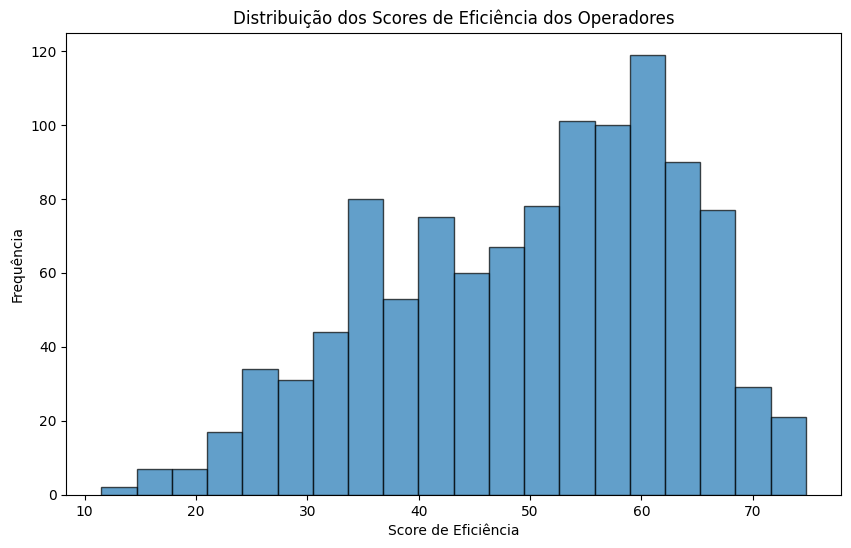

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
plt.hist(operator_volume['efficiency_score'], bins=20, alpha=0.7, edgecolor='black')
plt.title('Distribuição dos Scores de Eficiência dos Operadores')
plt.xlabel('Score de Eficiência')
plt.ylabel('Frequência')
plt.show()

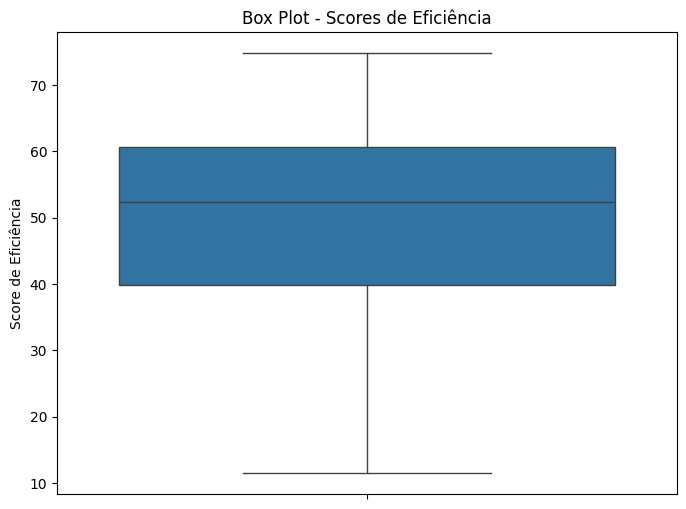

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=operator_volume['efficiency_score'])
plt.title('Box Plot - Scores de Eficiência')
plt.ylabel('Score de Eficiência')
plt.show()

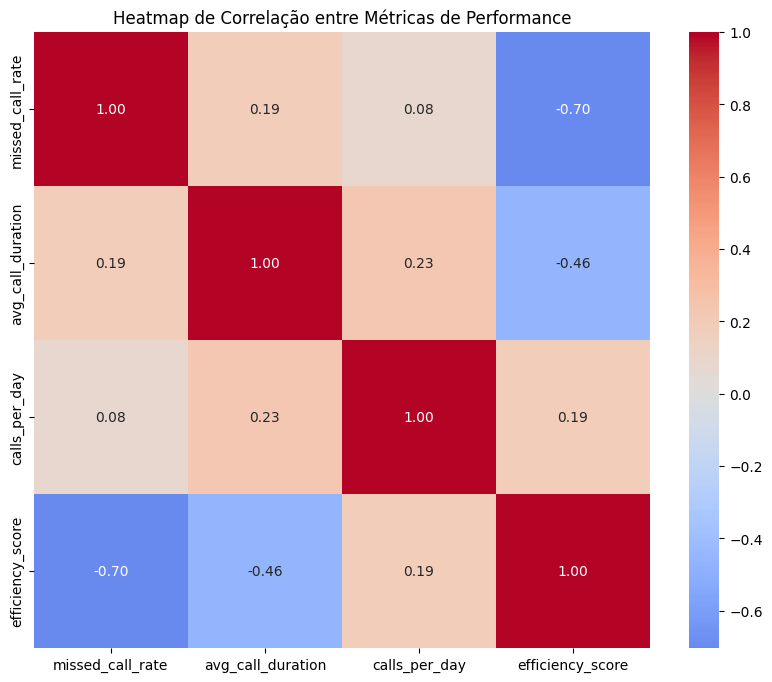

In [ ]:
correlation_matrix = operator_volume[['missed_call_rate', 'avg_call_duration', 'calls_per_day', 'efficiency_score']].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            square=True,
            fmt='.2f')
plt.title('Heatmap de Correlação entre Métricas de Performance')
plt.show()

Foi criado gráficos para ilustrar melhor o score de eficiência.

## CONCLUSÃO

A análise identificou um total de 275 operadores ineficientes, representando 25,2% do total, sendo 39 classificados como críticos (3,6%) e 236 como “precisa melhorar” (21,6%). Esses operadores apresentam características bem distintas em relação aos eficientes. A taxa de chamadas perdidas é significativamente mais alta, com mediana entre 46% e 60%, enquanto operadores eficientes ficam entre 20% e 30%. Além disso, os operadores ineficientes lidam com um volume muito maior de chamadas, com mediana de 291 atendimentos, em comparação com apenas 55 entre os eficientes. Outro ponto relevante é a duração das chamadas, que tende a ser mais longa e inconsistente, refletindo também uma alta variabilidade operacional, evidenciada por um desvio padrão mediano de 1.351 segundos, contra 273 segundos nos operadores eficientes.
A partir desses dados, foram identificados alguns padrões importantes de ineficiência. O primeiro é o paradoxo entre volume e qualidade: operadores ineficientes atendem cerca de cinco vezes mais chamadas, o que indica que maior volume não está associado a melhor desempenho, podendo inclusive prejudicar a qualidade do atendimento. Outro ponto é a inconsistência operacional, evidenciada pela alta variabilidade na duração das chamadas (com significância estatística, p < 0,001), sugerindo falta de padronização, possíveis lacunas de treinamento e processos pouco estruturados. Observa-se também a formação de um ciclo vicioso: chamadas mais longas aumentam o tamanho da fila, gerando pressão por rapidez, o que leva ao aumento de chamadas perdidas, retrabalho e, consequentemente, chamadas ainda mais longas. Por fim, a segmentação dos operadores mostra a necessidade de abordagens distintas, com 39 operadores críticos demandando intervenção imediata, enquanto 236 apresentam potencial de melhoria por meio de desenvolvimento estruturado.
Com base nesses insights, recomenda-se um conjunto de ações em diferentes horizontes de tempo. No curto prazo (0 a 30 dias), o foco deve estar nos operadores críticos, por meio de auditorias individuais de chamadas, programas de mentoria com operadores de alto desempenho e revisão da aderência aos processos, a fim de identificar falhas específicas. No médio prazo (1 a 3 meses), as ações devem se concentrar no grupo que precisa melhorar, com a implementação de programas de treinamento voltados para técnicas de resolução eficiente, uso de scripts padronizados e gestão do tempo por chamada, além da definição de métricas de acompanhamento, como metas graduais de redução da taxa de perda e monitoramento contínuo da variabilidade. Já no longo prazo (3 a 6 meses), recomenda-se uma abordagem estratégica que inclua a redistribuição da carga de trabalho, investigando por que operadores ineficientes recebem mais chamadas e implementando sistemas mais equilibrados, bem como uma análise aprofundada das causas raiz, considerando fatores como complexidade das chamadas, diferenças por turno, nível de experiência e qualidade do treinamento inicial. Por fim, é importante estabelecer um sistema de reconhecimento que incentive a melhoria contínua e promova a mentoria entre pares.
De forma geral, os resultados indicam que a ineficiência operacional está menos relacionada ao volume de chamadas e mais à falta de padronização e controle dos processos, reforçando a necessidade de intervenções estruturadas e orientadas por dados.